# **Задание 4.** Генеративные модели

## Импорт библиотек и модулей

In [1]:
%%capture
!pip install pytorch-model-summary
!pip install kagglehub

In [2]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchvision as tv
import torchvision.transforms.v2 as T

from pytorch_model_summary import summary

import kagglehub as kaggle
import datasets as ds

Зададим значение `seed` и зафиксируем его:

In [3]:
seed_value = 927

random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: mps


## Загрузка датасета

In [5]:
data_path = kaggle.dataset_download("jeffheaton/iris-computer-vision")
print(f"Path to the dataset: {data_path}")

Path to the dataset: /Users/dji/.cache/kagglehub/datasets/jeffheaton/iris-computer-vision/versions/1


## Реализация датасета

In [6]:
full_dataset = tv.datasets.ImageFolder(root=data_path, transform=None)

In [7]:
print(f"Изображений в датасете: {len(full_dataset)}")

Изображений в датасете: 421


Изображений достаточно мало, поэтому будем использовать аугментации:
* Resize – ресайз до заданного размера
* RandomHorizontalFlip – отражение по горизонтали с заданной вероятностью
* RandomVerticalFlip - отражение по вертикали с заданной вероятностью
* RandomAdjustSharpness - добавление резкости изображения

In [ ]:
def get_transform(train: bool = True):
    if train:
        return T.Compose([
            T.Resize((64, 64)),
            T.RandomHorizontalFlip(p=0.4),
            T.RandomVerticalFlip(p=0.4),
            T.RandomAdjustSharpness(sharpness_factor=1.6, p=0.3),
            T.ToTensor()
        ])
    else:
        return T.Compose([
            T.Resize((64, 64)),
            T.ToTensor()
        ])

In [9]:
class AugmentedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    
    def __len__(self):
        return len(self.subset)

In [10]:
train_size, val_size = 320, len(full_dataset) - 320
train_subset, val_subset = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed_value)
)

In [11]:
train_ds = AugmentedSubset(train_subset, transform=get_transform(train=True))
val_ds = AugmentedSubset(val_subset, transform=get_transform(train=False))

/opt/homebrew/anaconda3/envs/nn-arch-venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [12]:
BATCH_SIZE = 32
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Train: 320, Val: 101


## Реализация энкодера и декодера

In [14]:
class CustomEncoder(nn.Module):
    def __init__(self, latent):
        super().__init__()
        self.backbone = nn.Sequential(
            # 64x64x3 -> 32x32x16
            nn.Conv2d(3, 16, kernel_size=4, stride=2, padding=1, dilation=1, bias=False),
            nn.BatchNorm2d(16),
            nn.GELU(),
            # 32x32x16 -> 15x15x32
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1, dilation=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
            # 15x15x32 -> 8x8x64
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1, dilation=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            # 8x8x64 -> 4x4x64
            nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1, dilation=1, bias=False),
            nn.BatchNorm2d(64),
            nn.Dropout(0.1),
            nn.GELU()
        )

        self.flatten = nn.Flatten()
        self.mu = nn.Linear(64 * 4 * 4, latent)
        self.sigmasq = nn.Linear(64 * 4 * 4, latent)

    def forward(self, x):
        features = self.backbone(x)
        flattened = self.flatten(features)

        mu = self.mu(flattened)
        sigmasq = self.sigmasq(flattened)

        return mu, sigmasq

Энкодер на выходе отдает. параметры распределения, которое получено по картинкам трейнового набора данных. 

Декодер будет иметь противоположную с точки зрения архитектуры структуру.

In [15]:
class CustomDecoder(nn.Module):
    def __init__(self, latent):
        super().__init__()
        self.features = nn.Linear(latent, 64 * 4 * 4)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1, dilation=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, dilation=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1, dilation=1, bias=False),
            nn.BatchNorm2d(16),
            nn.GELU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1, dilation=1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, z):
        features = self.features(z).view(z.shape[0], 64, 4, 4)
        generated = self.deconv(features)
        return generated

## Реализация модели вариационного автоэнкодера **(VAE)**

In [16]:
class CustomVAE(nn.Module):
    def __init__(self, latent):
        super().__init__()
        self.enc = CustomEncoder(latent=latent)
        self.dec = CustomDecoder(latent=latent)

    def reparametrize(self, mu, sigmasq):
        sigma = torch.exp(0.5 * sigmasq)
        eps = torch.randn_like(sigma)
        return mu + eps * sigma
    
    def forward(self, x):
        mu, sigmasq = self.enc(x)
        z = self.reparametrize(mu, sigmasq)
        generated = self.dec(z)
        return mu, sigmasq, generated, x

## Лосс

In [17]:
def loss(mu, sigmasq, generated, x):
    similarity = F.mse_loss(generated, x, reduction='sum') / x.shape[0]
    kl_divergence = -0.5 * torch.sum(1 + sigmasq - mu.pow(2) - sigmasq.exp()) / x.shape[0]
    summary_loss = similarity + kl_divergence
    return summary_loss, similarity, kl_divergence

## Инициализация модели

In [18]:
latent = 512
epochs = 200
vae = CustomVAE(latent).to(device)
optimizer = torch.optim.AdamW(vae.parameters(), lr=4e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

## Трейн

In [19]:
for epoch in tqdm(range(epochs)):
    # train 
    vae.train()
    epoch_loss = 0
    epoch_sim_loss = 0
    epoch_kl_loss = 0

    for imgs, _ in train_dl:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        batch_mu, batch_sigmasq, batch_gen, batch_gt = vae(imgs)
        total_loss, sim_loss, kl_loss = loss(batch_mu, batch_sigmasq, batch_gen, batch_gt)
        total_loss.backward()
        optimizer.step()
        epoch_loss += total_loss.item() / len(train_dl)
        epoch_sim_loss += sim_loss.item() / len(train_dl)
        epoch_kl_loss += kl_loss.item() / len(train_dl)

    # validation
    vae.eval()
    epoch_loss_val = 0
    epoch_sim_loss_val = 0
    epoch_kl_loss_val = 0
    with torch.no_grad():
        for imgs, _ in val_dl:
            imgs = imgs.to(device)
            batch_mu_val, batch_sigmasq_val, batch_gen_val, batch_gt_val = vae(imgs)
            total_loss_val, sim_loss_val, kl_loss_val = loss(
                batch_mu_val, batch_sigmasq_val, batch_gen_val, batch_gt_val
            )
            epoch_loss_val += total_loss_val.item() / len(val_dl)
            epoch_sim_loss_val += sim_loss_val.item() / len(val_dl)
            epoch_kl_loss_val += kl_loss_val.item() / len(val_dl)
    
    scheduler.step(epoch_loss_val / len(val_dl))

    # verbose
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}: \nTrain Loss: {epoch_loss} | {epoch_sim_loss} | {epoch_kl_loss}\nVal Loss: {epoch_loss_val} | {epoch_sim_loss_val} | {epoch_kl_loss_val}")

  0%|          | 1/200 [00:00<02:55,  1.13it/s]

Epoch: 0: 
Train Loss: 898.4495971679688 | 854.6756347656249 | 43.773971557617195
Val Loss: 816.1014709472656 | 782.1203918457031 | 33.981069564819336


  6%|▌         | 11/200 [00:04<01:03,  2.98it/s]

Epoch: 10: 
Train Loss: 463.03497009277334 | 430.60084228515626 | 32.43412704467773
Val Loss: 452.8510437011719 | 422.1342315673828 | 30.716813564300537


 10%|█         | 21/200 [00:07<01:03,  2.80it/s]

...

 90%|█████████ | 181/200 [01:01<00:06,  2.98it/s]

Epoch: 180: 
Train Loss: 337.07240600585936 | 283.19281005859375 | 53.879594802856445
Val Loss: 340.18934631347656 | 289.3136291503906 | 50.875722885131836


 96%|█████████▌| 191/200 [01:04<00:02,  3.03it/s]

Epoch: 190: 
Train Loss: 334.49085998535156 | 279.6858245849609 | 54.80503768920898
Val Loss: 339.4075698852539 | 288.1136703491211 | 51.29389190673828


100%|██████████| 200/200 [01:07<00:00,  2.95it/s]


## Валидация и генерация новых изображений

In [20]:
def visualize_val_data(model, dl, device, num_samples=6):
    model.eval()
    images, labels = next(iter(dl))
    images = images[15:num_samples+15].to(device)
    labels = labels[15:num_samples+15]

    with torch.no_grad():
        _, _, generated, _ = model(images)

    images = images.cpu()
    generated = generated.cpu()

    plt.figure(figsize=(2 * num_samples - 1, 5))
    for idx in range(num_samples):
        plt.subplot(2, num_samples, idx + 1)
        plt.imshow(images[idx].permute(1, 2, 0))
        plt.title(f"Label: {labels[idx]}")
        plt.axis("off")
        plt.subplot(2, num_samples, idx + 1 + num_samples)
        plt.imshow(generated[idx].permute(1, 2, 0))
        plt.axis("off")

    plt.suptitle("Validation of Generating Images from Val Subset")

    plt.tight_layout()
    plt.show()

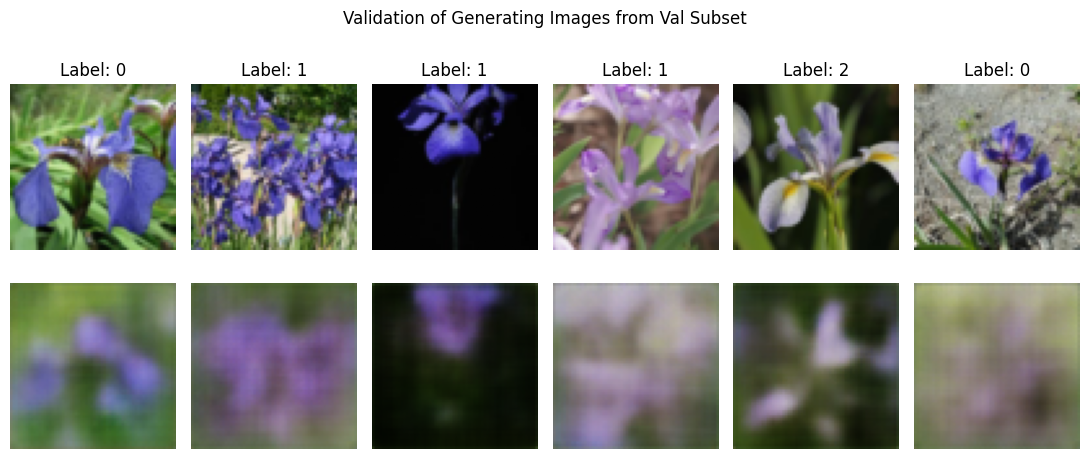

In [27]:
visualize_val_data(vae, val_dl, device)

In [22]:
def visualize_new_gens(model, latent, device, num_samples=6):
    model.eval()

    with torch.no_grad():
        z = torch.randn(num_samples, latent).to(device)
        generated_images = model.dec(z).cpu()

    plt.figure(figsize=(2 * num_samples - 1, 2.5))
    for idx in range(num_samples):
        plt.subplot(1, num_samples, idx + 1)
        plt.imshow(generated_images[idx].permute(1, 2, 0))
        plt.axis("off")

    plt.suptitle("Generated Images")

    plt.tight_layout()
    plt.show()

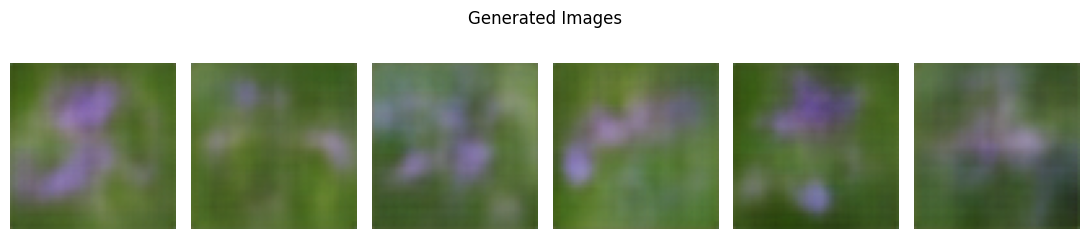

In [34]:
generated_samples = visualize_new_gens(vae, latent, device, num_samples=6)

## Вывод

Общие очертания как на картинках из валидационного набора, так и на полностью сгенерированных, соответствуют изображениям ирисов. При этом заметно, что модель испытывает достаточно большие трудности с генерацией более детализированных картинок. 

Обучение достаточно быстрое, поэтому немного поэкспериментировал с параметрами и нашел подходящие. 

Большую роль сыграло то, что мало картинок в датасете - всего 421. Из-за этого даже с использованными аугментациями пространство уникальных сэмплов имеет достаточно малую размерность.